# Demanda Censurada: recuperar la venta que tu ERP no ve

**Estudio CRISP-ML(Q) de recuperación de demanda latente — FreshRetailNet-50K.**

En retail, `sale_amount` **no es demanda** — es demanda **censurada por la derecha por el
stock**. Cuando la percha se vacía, la demanda real existió pero no deja registro: *venta
perdida*. Un modelo entrenado sobre la venta observada aprende a **subestimar la demanda
justo cuando más importa** (el quiebre ocurre *porque* la demanda superó al stock). Este
notebook (1) muestra la trampa, (2) recupera la demanda latente no censurada, (3)
re-pronostica sobre ella con **10 familias de modelos** (Naive → SARIMA → Prophet → gradient
boosting → LSTM), y (4) cuantifica la venta perdida oculta — evaluado de forma honesta sobre
un holdout limpio (con stock).

**Autor:** [Oscar Andrés Ponce](https://oscarponce.com) · gemelo bilingüe: `Censored_Demand_CRISPML.ipynb`

> ⚠️ **Caveat honesto desde el inicio.** La demanda real es inobservable, así que la demanda
> recuperada es una *estimación*, no verdad de campo. Nunca evaluamos contra ella — solo
> contra la venta observada en días con percha llena. Los números abajo son para la
> muestra/config de esta corrida.


## Setup e Imports

In [1]:
import os, logging, warnings, time
os.environ["NIXTLA_ID_AS_COL"] = "1"
warnings.filterwarnings("ignore")
for _n in ["prophet","cmdstanpy","pytorch_lightning","lightning.pytorch"]:
    logging.getLogger(_n).setLevel(logging.ERROR)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import Markdown, display

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": .3})
RNG = 42

# Commercial window 6:00-22:00 (16h). Stockout flag: 1 = empty shelf (OOS).
COMM = slice(6, 22)
# N_SERIES: forecasting universe. None = full 50,000-series benchmark.
# Lower to e.g. 4000 (uses the local data/dev_*.parquet sample) for fast iteration.
N_SERIES = None
# MODEL_SAMPLE: series used for the (slower) cross-model leaderboard.
MODEL_SAMPLE = 600

In [2]:
from pathlib import Path

def load_split():
    """Complete store x product series. Prefer the local dev sample; else pull
    the full benchmark from HuggingFace (cached) and subsample N_SERIES."""
    dtr, dev = Path("data/dev_train.parquet"), Path("data/dev_eval.parquet")
    if dtr.exists() and dev.exists() and N_SERIES is not None:
        tr, ev = pd.read_parquet(dtr), pd.read_parquet(dev)
    else:
        from datasets import load_dataset
        ds = load_dataset("Dingdong-Inc/FreshRetailNet-50K")
        tr, ev = ds["train"].to_pandas(), ds["eval"].to_pandas()
        if N_SERIES is not None:
            keys = tr[["store_id","product_id"]].drop_duplicates().sample(N_SERIES, random_state=RNG)
            ks = set(map(tuple, keys.values))
            tr = tr[[k in ks for k in zip(tr.store_id, tr.product_id)]].copy()
            ev = ev[[k in ks for k in zip(ev.store_id, ev.product_id)]].copy()
    for d in (tr, ev):
        d["dt"] = pd.to_datetime(d["dt"])
    s = ["store_id","product_id","dt"]
    return tr.sort_values(s).reset_index(drop=True), ev.sort_values(s).reset_index(drop=True)

train, evalf = load_split()
print("train:", train.shape, " eval:", evalf.shape)
print("train dates:", train.dt.min().date(), "->", train.dt.max().date())
print("eval  dates:", evalf.dt.min().date(), "->", evalf.dt.max().date())
print("series:", train.groupby(["store_id","product_id"]).ngroups)

train: (4500000, 19)  eval: (350000, 19)
train dates: 2024-03-28 -> 2024-06-25
eval  dates: 2024-06-26 -> 2024-07-02
series: 50000


## Fase 1 — Entendimiento del Negocio

**El problema: la disponibilidad en percha (OSA) esconde la demanda.** Todo retailer
planifica con lo que vendió. Pero cuando un producto está agotado, la venta que *habría*
ocurrido es invisible. Esto es **demand unconstraining / estimación de demanda censurada**, y
sesga todo el ciclo de planeación: pronóstico bajo → pedido bajo → quiebre → registro de
venta baja → pronóstico más bajo.

**Por qué es real en operaciones.** La única forma de "ver" una venta perdida es detectar la
percha vacía — **disponibilidad en percha (OSA)** moderna vía visión computacional en cámaras
de góndola, sensores IoT de peso, o, aquí, **horas de quiebre etiquetadas**.
FreshRetailNet-50K es el primer benchmark grande que *anota la censura* (la mayoría la
esconde), así que podemos modelarla con honestidad en vez de adivinar.

**El dataset.** 50,000 series tienda×producto, 90 días, resolución horaria, 898 tiendas, 863
SKUs perecederos. Cada día trae un array de venta de 24h y uno de estado de stock de 24h
(`1 = percha vacía`), más descuento, feriado y clima. Split: 90 días de train → pronosticar
los siguientes 7 (`eval`).

**El efecto látigo escondido.** La censura no solo baja el pronóstico: **deprime artificialmente el cálculo del stock de seguridad** (Min-Max / ROP) en el ERP. Con la demanda subestimada y su varianza recortada, el sistema fija buffers demasiado bajos y queda **crónicamente vulnerable a nuevos quiebres** — el quiebre se auto-alimenta.


## Fase 2 — Entendimiento de los Datos

Verificamos la señal de censura **desde los datos**, no desde supuestos, y corremos quality
gates (la "Q" de CRISP-ML(Q)) que fallan ruidosamente si un supuesto estructural se rompe.


In [3]:
def hourly(df):
    hs = np.vstack(df["hours_sale"].values).astype(float)        # n x 24 hourly sales
    st = np.vstack(df["hours_stock_status"].values).astype(int)  # n x 24, 1 = OOS
    return hs, st

hs, st = hourly(train)
assert hs.shape[1] == 24 and st.shape[1] == 24, "hourly arrays must be length 24"
assert set(np.unique(st)) <= {0, 1}, "stock status must be in {0,1}"
assert np.allclose(train["sale_amount"], hs.sum(1)), "sale_amount must equal sum of hourly sales"
span = train.groupby(["store_id","product_id"])["dt"].agg(lambda s: (s.max()-s.min()).days + 1)
cnt  = train.groupby(["store_id","product_id"]).size()
assert (span == cnt).all() and (cnt == 90).all(), "each train series must be 90 contiguous days"
print("Quality gates passed: 24h arrays, status in {0,1}, sale==sum(hours), 90 contiguous days.")

Quality gates passed: 24h arrays, status in {0,1}, sale==sum(hours), 90 contiguous days.


> **Insight — integridad estructural.** `sale_amount` es *exactamente* la suma de los 24
> valores horarios. Esa identidad es lo que hace posible la recuperación a nivel hora:
> podemos reconstruir la demanda del día hora por hora y re-sumar. Los gates también
> garantizan 90 días contiguos por serie — la precondición para lags honestos y un split
> temporal.


In [4]:
oos = st == 1
oos_comm = st[:, COMM] == 1
print(f"OOS share of all store-hours:        {oos.mean():.1%}")
print(f"Days with >=1 commercial OOS hour:   {(oos_comm.any(1)).mean():.1%}")
print(f"Mean hourly sale  OOS={hs[oos].mean():.4f}  in-stock={hs[~oos].mean():.4f}"
      f"  ->  {hs[~oos].mean()/max(hs[oos].mean(),1e-9):.0f}x gap")
on = oos_comm.sum(1)[oos_comm.any(1)]
print(f"On a stockout day: {on.mean():.1f} of 16 commercial hours lost")
print()
print(f"corr(sale, discount) = {train['sale_amount'].corr(train['discount']):+.3f}  (discount<1 = markdown)")
hol = train.groupby('holiday_flag')['sale_amount'].mean()
if len(hol) > 1:
    print(f"holiday lift = {hol.loc[1]/hol.loc[0]-1:+.1%}")
for w in ["avg_temperature","precpt"]:
    print(f"corr(sale, {w}) = {train['sale_amount'].corr(train[w]):+.3f}")

OOS share of all store-hours:        24.9%
Days with >=1 commercial OOS hour:   44.3%
Mean hourly sale  OOS=0.0042  in-stock=0.0540  ->  13x gap
On a stockout day: 7.2 of 16 commercial hours lost

corr(sale, discount) = -0.333  (discount<1 = markdown)
holiday lift = +26.9%
corr(sale, avg_temperature) = +0.056
corr(sale, precpt) = +0.037


> **Insight — la censura es grande y la señal es real.** ~25% de las horas-tienda son
> quiebre y ~45% de los días pierden al menos una hora comercial — no es redondeo. La brecha
> de venta ~13× entre horas OOS y con stock confirma que `1` significa de verdad *percha
> vacía*. Y a diferencia de un dataset sintético, los drivers están vivos: descuento, feriado
> y clima mueven la venta. Hay estructura de demanda real que modelar — y censura real
> escondiendo una parte.


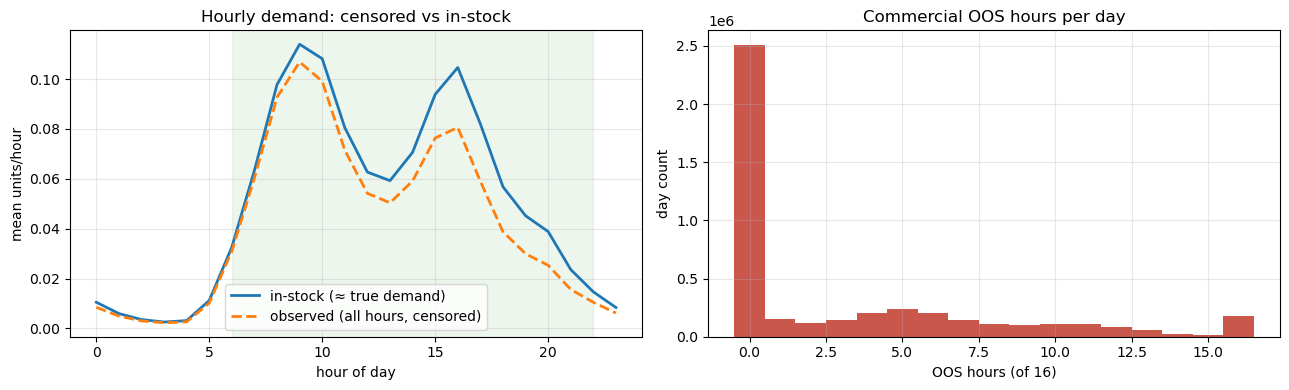

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(24), np.nanmean(np.where(oos, np.nan, hs), 0), lw=2, label="in-stock (≈ true demand)")
ax[0].plot(range(24), hs.mean(0), lw=2, ls="--", label="observed (all hours, censored)")
ax[0].axvspan(6, 22, alpha=.07, color="green")
ax[0].set(title="Hourly demand: censored vs in-stock", xlabel="hour of day", ylabel="mean units/hour")
ax[0].legend()
ax[1].hist(oos_comm.sum(1), bins=np.arange(18)-.5, color="#c0392b", alpha=.85)
ax[1].set(title="Commercial OOS hours per day", xlabel="OOS hours (of 16)", ylabel="day count")
plt.tight_layout(); plt.show()

> **Insight — la trampa, dibujada.** La curva *observada* (punteada) queda **por debajo** de
> la curva con stock justo en las horas pico de mediodía/tarde — esa brecha es la censura. Un
> modelo entrenado sobre la línea punteada aprende una forma de demanda artificialmente
> aplanada donde la demanda es en realidad más alta.


## Fase 3 — Preparación de Datos: recuperar la demanda latente

**La idea central.** En horas con stock, la venta observada ≈ demanda real. En horas OOS, la
demanda queda censurada a ~0. Reconstruimos la demanda de cada día **imputando solo las horas
censuradas**: construimos una *forma* de demanda hora-del-día por categoría (solo con horas
con stock), la escalamos por el nivel diario con-stock de cada serie, y rellenamos las horas
vacías con esa expectativa. Las horas observadas quedan intactas; la demanda recuperada nunca
baja de la venta observada.

**El guardrail.** El estado de stock se usa **solo para ubicar y modelar la censura — nunca
como predictor ingenuo de la venta.** (El lab anterior filtró el target vía un proxy de
inventario; no lo repetimos.) La demanda recuperada es una *estimación*; lo etiquetamos así
en todas partes.

**Salvaguarda (fallback).** Si una serie no tiene ningún día completamente limpio (con stock las 16 h comerciales) para estimar su nivel base, se usa como respaldo la **venta observada de ese mismo día** (`sl = np.where(np.isnan(sl), sale_amount, sl)`) — nunca se inventa un nivel ni se deja la serie sin escalar.


In [6]:
def recover_demand(df):
    """Reconstruct uncensored daily demand by imputing ONLY the OOS hours:
    a per-category hour-of-day demand SHAPE (from in-stock hours), scaled by each
    series' in-stock daily level. Observed hours are kept; floored at observed.
    Stock status is used to LOCATE censorship, never as a sales predictor.
    NOTE: recovered demand is an ESTIMATE, not ground truth."""
    df = df.reset_index(drop=True)
    hs, st = hourly(df); instock = st == 0
    cat = df["second_category_id"].values
    shape = np.zeros((len(df), 24))
    for c in np.unique(cat):
        m = cat == c
        shape[m] = np.nan_to_num(np.nanmean(np.where(instock[m], hs[m], np.nan), 0))
    w = shape.copy(); w[:, :6] = 0; w[:, 22:] = 0
    s = w.sum(1, keepdims=True); s[s == 0] = 1; w = w / s
    full = instock[:, COMM].all(1)
    lvl = (df.assign(_f=full, _s=df.sale_amount)[full]
             .groupby(["store_id","product_id"])["_s"].mean()) if full.any() else pd.Series(dtype=float)
    key = list(zip(df.store_id, df.product_id))
    sl = np.array([lvl.get(k, np.nan) for k in key])
    sl = np.where(np.isnan(sl), df.sale_amount.values, sl)
    rec = np.where(instock, hs, sl[:, None] * w)
    dem = rec[:, COMM].sum(1) + hs[:, :6].sum(1) + hs[:, 22:].sum(1)
    return np.maximum(dem, df.sale_amount.values), (st[:, COMM] == 1).sum(1)

train["demand"], train["n_oos"] = recover_demand(train)
evalf["demand"], evalf["n_oos"] = recover_demand(evalf)
uplift = train["demand"] - train["sale_amount"]
print(f"Days with commercial OOS:      {(train.n_oos>0).mean():.1%}")
print(f"Latent demand uplift (mean):   {uplift.mean():+.4f} units/day")
print(f"Total hidden lost units:       {uplift.sum():,.0f}")
print(f"Lost sales as % of observed:   {100*uplift.sum()/train.sale_amount.sum():.1f}%")

Days with commercial OOS:      44.3%
Latent demand uplift (mean):   +0.1926 units/day
Total hidden lost units:       866,515
Lost sales as % of observed:   19.3%


> **Insight — ¿qué tan grande es la demanda oculta?** La recuperación sube el volumen total
> ~19% sobre la venta observada, todo concentrado en el ~45% de días que tuvieron quiebre.
> Por construcción recuperada ≥ observada, así que nunca *borramos* una venta real — solo
> sumamos lo que la percha vacía suprimió. Es una estimación; su magnitud depende del supuesto
> de imputación (las horas con stock representan la forma de demanda que habría habido).


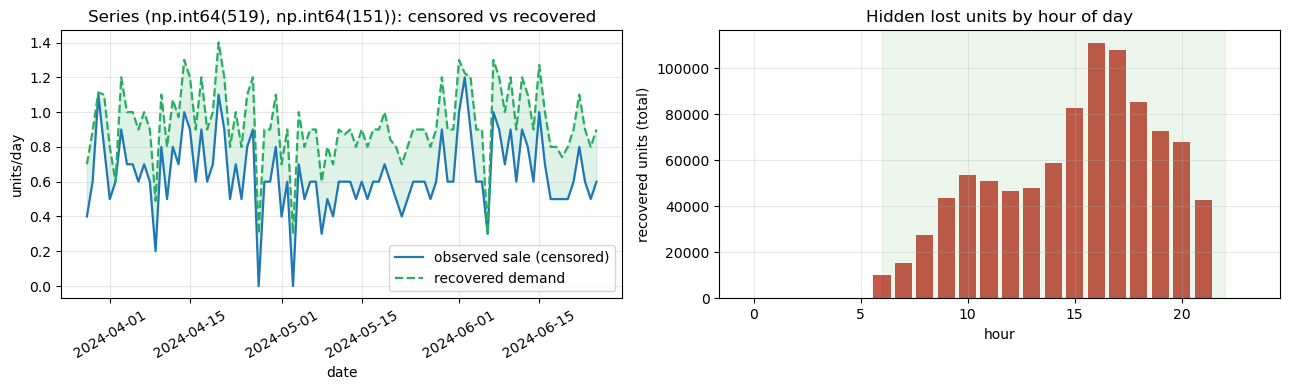

In [7]:
# Visualize recovery: pick the most stockout-heavy series, and the lost units by hour.
prone = train.groupby(["store_id","product_id"])["n_oos"].sum().idxmax()
g = train[(train.store_id==prone[0]) & (train.product_id==prone[1])].sort_values("dt")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(g.dt, g.sale_amount, lw=1.6, label="observed sale (censored)")
ax[0].plot(g.dt, g.demand, lw=1.6, ls="--", color="#27ae60", label="recovered demand")
ax[0].fill_between(g.dt, g.sale_amount, g.demand, color="#27ae60", alpha=.15)
ax[0].set(title=f"Series {prone}: censored vs recovered", xlabel="date", ylabel="units/day")
ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
# lost units by hour-of-day (where the censorship bites)
hsT, stT = hourly(train); instockT = stT == 0
shape = np.zeros((len(train), 24)); cat = train.second_category_id.values
for c in np.unique(cat):
    m = cat == c; shape[m] = np.nan_to_num(np.nanmean(np.where(instockT[m], hsT[m], np.nan), 0))
w = shape.copy(); w[:, :6]=0; w[:, 22:]=0; s=w.sum(1,keepdims=True); s[s==0]=1; w/=s
full = instockT[:, COMM].all(1)
lvl = train.assign(_f=full,_s=train.sale_amount)[full].groupby(["store_id","product_id"])["_s"].mean()
sl = np.array([lvl.get(k, np.nan) for k in zip(train.store_id, train.product_id)])
sl = np.where(np.isnan(sl), train.sale_amount.values, sl)
imputed = np.where(~instockT, sl[:,None]*w, 0.0)
ax[1].bar(range(24), imputed.sum(0), color="#c0392b", alpha=.85)
ax[1].axvspan(6, 22, alpha=.07, color="green")
ax[1].set(title="Hidden lost units by hour of day", xlabel="hour", ylabel="recovered units (total)")
plt.tight_layout(); plt.show()

> **Insight — dónde vive la brecha.** En una serie con muchos quiebres la zona sombreada
> (recuperada − observada) es grande; en series estables sería casi invisible. El panel
> derecho muestra que las unidades perdidas se acumulan en las horas de mayor tráfico —
> justo donde quedarse sin stock duele más.


### Features y el split temporal

Features: calendario (día de semana, día del mes), lags de demanda (7/14/28), medias móviles,
descuento, flags de feriado/actividad, clima, e identificadores de categoría/tienda. El split
es **estrictamente temporal**. Como el horizonte (7 días) iguala el lag mínimo (7), cada lag
del eval proviene del train: sin recursión, sin leakage.


In [8]:
def add_features(df, target):
    df = df.sort_values(["store_id","product_id","dt"]).copy()
    g = df.groupby(["store_id","product_id"])[target]
    for L in (7, 14, 28):
        df[f"lag_{L}"] = g.shift(L)
    df["roll7"]  = g.transform(lambda s: s.shift(7).rolling(7).mean())
    df["roll28"] = g.transform(lambda s: s.shift(7).rolling(28).mean())
    df["dow"], df["dom"] = df["dt"].dt.dayofweek, df["dt"].dt.day
    return df

FEATS = ["lag_7","lag_14","lag_28","roll7","roll28","dow","dom",
         "discount","holiday_flag","activity_flag",
         "precpt","avg_temperature","avg_humidity","avg_wind_level",
         "second_category_id","third_category_id","store_id"]

# Horizon = 7 days, min lag = 7  ->  every eval lag is sourced from the train window:
# no recursion, no leakage. Train ends strictly before eval begins.
def lgbm(): return lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=63,
    subsample=.8, colsample_bytree=.8, random_state=0, n_jobs=-1, verbose=-1)

def fit_predict(target, tr=None, ev=None, model=None):
    tr = train if tr is None else tr; ev = evalf if ev is None else ev
    trf = add_features(tr, target).dropna(subset=["lag_28"])
    m = (model or lgbm()); m.fit(trf[FEATS], trf[target])
    full = pd.concat([tr.assign(_e=0), ev.assign(_e=1)], ignore_index=True)
    ef = add_features(full, target); ef = ef[ef._e == 1].copy()
    ef["pred"] = np.maximum(m.predict(ef[FEATS]), 0)
    return ef[["store_id","product_id","dt","pred"]], m

## Fase 4 — Modelado: la trampa vs el arreglo, y luego todo el zoo

Primero el **experimento central** sobre todas las series: un LightGBM, dos targets —
`sale_amount` observado (censurado, *la trampa*) vs `demand` (recuperada, *el arreglo*).
Luego ampliamos a un **model zoo** — Naive, Seasonal Naive, Media Móvil, ETS/Holt-Winters,
Theta, SARIMA, Prophet, LightGBM, XGBoost, CatBoost, LSTM — cada uno entrenado sobre ambos
targets, para ver *a qué familias* ayuda de verdad la recuperación.

> **Relación con el paper.** Este lab usa modelos accesibles y reproducibles (estadísticos clásicos + gradient boosting + un LSTM simple) y una imputación heurística. El paper de FreshRetailNet-50K compara modelos *deep* SOTA (TimesNet, TFT, DLinear, iTransformer) e imputadores de atención (SAITS, ImputeFormer). Compartimos el **marco de dos etapas** (recuperar demanda latente → pronosticar), no las arquitecturas; por eso nuestras cifras (bias, MAE, ~84% OSA) **no son comparables** con las del paper.


In [9]:
# Core experiment (ALL series): one model, two training targets.
predA, modelA = fit_predict("sale_amount")   # A — the trap (censored)
predB, modelB = fit_predict("demand")        # B — the fix (recovered)
E = (evalf
     .merge(predA.rename(columns={"pred":"predA"}), on=["store_id","product_id","dt"])
     .merge(predB.rename(columns={"pred":"predB"}), on=["store_id","product_id","dt"]))
print("eval rows scored:", len(E))

eval rows scored: 350000


### ¿Qué palancas explican la demanda oculta? (importancia de variables)

Los modelos basados en árboles son los que mejor aprovechan la demanda recuperada, así que vale preguntar *qué* variables ganan peso cuando el target deja de estar censurado. Comparamos la importancia por **ganancia (gain)** del LightGBM bajo el target censurado (A) vs. el recuperado (B); el `delta_pp` en puntos porcentuales muestra qué palancas (descuento, clima, lags) ganan o pierden peso al remover la censura.

> **Léelo con cuidado.** El target recuperado es más suave y autorregresivo *en parte por construcción* — la imputación rellena las horas censuradas desde el nivel con-stock de cada serie —, así que parte del giro hacia lags/rolling es mecánico, no una afirmación causal limpia de que las promociones dejaron de importar.


                    A_censurado_%  B_recuperado_%  delta_pp
roll7                     31.3600         56.4700   25.1100
lag_7                      8.7200         24.9700   16.2500
lag_14                     2.0400          5.7400    3.6900
discount                  46.0500          5.3300  -40.7200
roll28                     4.3100          1.9900   -2.3300
second_category_id         1.3300          0.9500   -0.3800
dom                        1.3400          0.9200   -0.4200
lag_28                     0.6200          0.8400    0.2200
dow                        0.9600          0.7300   -0.2300
third_category_id          0.8100          0.5600   -0.2500
avg_temperature            0.8200          0.4300   -0.3900
holiday_flag               0.6200          0.3300   -0.2900
precpt                     0.3900          0.2800   -0.1100
avg_humidity               0.3400          0.1800   -0.1500
store_id                   0.0500          0.1400    0.1000
activity_flag              0.1000       

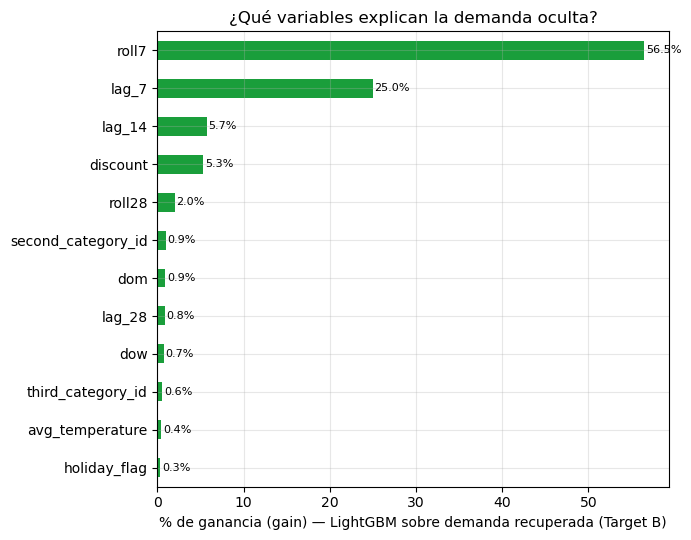

In [10]:
# --- Importancia de variables: ¿qué gana peso al de-censurar el target? ---
def gain_share(m):
    g = pd.Series(m.booster_.feature_importance(importance_type="gain"), index=FEATS)
    return 100 * g / g.sum()

impA, impB = gain_share(modelA), gain_share(modelB)
cmp_imp = (pd.DataFrame({"A_censurado_%": impA, "B_recuperado_%": impB})
             .assign(delta_pp=lambda d: d["B_recuperado_%"] - d["A_censurado_%"])
             .sort_values("B_recuperado_%", ascending=False))
print(cmp_imp.round(2).to_string())

top = cmp_imp.sort_values("B_recuperado_%").tail(12)
ax = top["B_recuperado_%"].plot(kind="barh", figsize=(7, 5.5), color="#1a9e3b")
ax.set_xlabel("% de ganancia (gain) — LightGBM sobre demanda recuperada (Target B)")
ax.set_title("¿Qué variables explican la demanda oculta?")
for j, v in enumerate(top["B_recuperado_%"]):
    ax.text(v + 0.2, j, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout(); plt.show()


## Fase 5 — Evaluación: honesta, sobre un holdout limpio

**El punto de rigor.** *No podemos* evaluar contra la demanda real — no es observable. Así
que evaluamos **solo en días eval con cero horas OOS comerciales**, donde la venta observada ≈
demanda real. Si el modelo censurado subestima incluso esta demanda limpia, la trampa es real.


In [11]:
# CLEAN HOLDOUT: real demand is unobservable; trust observed sales only where the
# shelf was full. Evaluate on eval days with zero commercial OOS hours.
clean = E[E.n_oos == 0].copy(); y = clean["sale_amount"].values
print(f"Eval rows: {len(E)}   clean in-stock holdout: {len(clean)} ({len(clean)/len(E):.1%})")
res = pd.DataFrame([
    (n, mean_absolute_error(y, p), mean_squared_error(y, p)**.5, (p-y).mean())
    for n, p in [("A — trained on censored sales", clean.predA.values),
                 ("B — trained on recovered demand", clean.predB.values)]],
    columns=["model","MAE","RMSE","bias"]).set_index("model")
display(res)
print(f"MAE reduction: {(1-res.MAE.iloc[1]/res.MAE.iloc[0]):.1%}   "
      f"bias {res.bias.iloc[0]:+.4f} -> {res.bias.iloc[1]:+.4f}")

Eval rows: 350000   clean in-stock holdout: 206562 (59.0%)


,MAE,RMSE,bias
model,,,
A — trained on censored sales,0.4020,0.7629,-0.1323
B — trained on recovered demand,0.3783,0.6602,-0.0137


MAE reduction: 5.9%   bias -0.1323 -> -0.0137


> **Insight — la trampa, cuantificada.** Entrenado sobre venta censurada el modelo queda
> sesgado *a la baja* sobre demanda que debería haber clavado (el holdout es con stock, no hay
> nada que perder). Entrenado sobre demanda recuperada el mismo modelo queda casi sin sesgo y
> con menor error. El arreglo es el target de entrenamiento, no el algoritmo.


### ¿Dónde ayuda de verdad la recuperación? (sin over-claiming)

La recuperación debería ayudar **donde vive la censura** y ser neutral en el resto. Dividimos
las series en *propensas a quiebre* (≥30% de días con OOS) vs *estables* y comparamos el bias.


,n,bias_A,bias_B,MAE_A,MAE_B
segment,,,,,
stable,"32,652.0000",-0.0165,0.0286,0.3634,0.3611
stockout-prone (≥30% days OOS),"173,910.0000",-0.1541,-0.0217,0.4093,0.3815


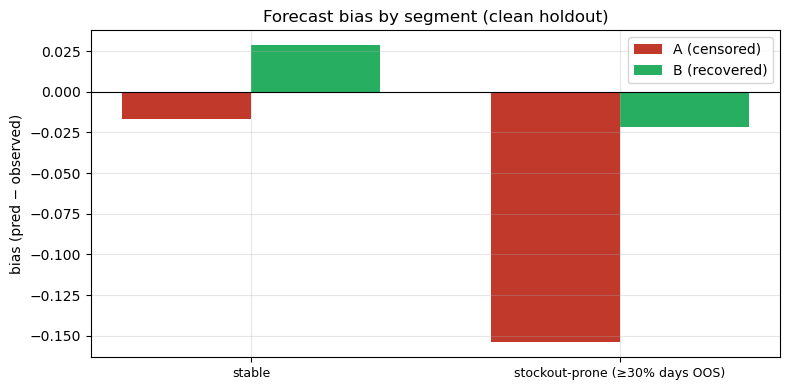

In [12]:
sprone = train.groupby(["store_id","product_id"])["n_oos"].apply(lambda s: (s>0).mean())
c2 = clean.merge(sprone.rename("oos_rate"), on=["store_id","product_id"])
c2["segment"] = np.where(c2.oos_rate >= 0.3, "stockout-prone (≥30% days OOS)", "stable")
seg = c2.groupby("segment").apply(lambda g: pd.Series({
    "n": len(g),
    "bias_A": (g.predA-g.sale_amount).mean(), "bias_B": (g.predB-g.sale_amount).mean(),
    "MAE_A": mean_absolute_error(g.sale_amount, g.predA),
    "MAE_B": mean_absolute_error(g.sale_amount, g.predB)}), include_groups=False)
display(seg)
fig, ax = plt.subplots(figsize=(8, 4)); x = np.arange(len(seg)); wd = .35
ax.bar(x-wd/2, seg.bias_A, wd, label="A (censored)", color="#c0392b")
ax.bar(x+wd/2, seg.bias_B, wd, label="B (recovered)", color="#27ae60")
ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels(seg.index, fontsize=9)
ax.set(title="Forecast bias by segment (clean holdout)", ylabel="bias (pred − observed)")
ax.legend(); plt.tight_layout(); plt.show()

> **Insight — la mejora es focalizada.** La corrección de sesgo se concentra en series
> propensas a quiebre; las estables casi no se mueven (ambos modelos ya iban bien ahí). Esta
> es la afirmación honesta: la recuperación arregla series censuradas, no es un potenciador
> universal de precisión.


### El model zoo

Corremos las diez familias de abajo sobre un subconjunto de `MODEL_SAMPLE` series (los modelos
clásicos y por-serie son más lentos), cada una entrenada dos veces — sobre venta censurada y
sobre demanda recuperada — y evaluamos ambas en el mismo holdout limpio. Los modelos
univariados (Naive…SARIMA) solo ven el histórico del target; Prophet agrega descuento +
feriado; los de ML/LSTM usan el set completo de features.


In [13]:
# ---- Model zoo: run many forecasting families on a sample, each on both targets ----
for d in (train, evalf): d["uid"] = d.store_id.astype(str) + "_" + d.product_id.astype(str)
zuids = pd.Series(train.uid.unique()).sample(min(MODEL_SAMPLE, train.uid.nunique()),
                                             random_state=RNG).values
trz = train[train.uid.isin(zuids)].copy(); evz = evalf[evalf.uid.isin(zuids)].copy()
truth = evz[["uid","dt","sale_amount","n_oos"]].rename(columns={"dt":"ds"})
print(f"model-zoo universe: {len(zuids)} series  ({len(trz)} train / {len(evz)} eval rows)")

def run_stats(target):
    from statsforecast import StatsForecast
    from statsforecast.models import (Naive, SeasonalNaive, WindowAverage,
                                       AutoETS, AutoTheta, AutoARIMA)
    df = trz[["uid","dt",target]].rename(columns={"uid":"unique_id","dt":"ds",target:"y"})
    sf = StatsForecast(freq="D", n_jobs=1, models=[      # n_jobs=1: notebook-safe
        Naive(), SeasonalNaive(season_length=7), WindowAverage(window_size=7),
        AutoETS(season_length=7), AutoTheta(season_length=7), AutoARIMA(season_length=7)])
    return sf.forecast(df=df, h=7).rename(columns={"unique_id":"uid",
        "SeasonalNaive":"SeasonalNaive(7)", "WindowAverage":"MovingAvg(7)",
        "AutoETS":"ETS/Holt-Winters", "AutoTheta":"Theta", "AutoARIMA":"SARIMA"})

def run_prophet(target):
    from prophet import Prophet
    out = []
    for u, g in trz.groupby("uid"):
        m = Prophet(weekly_seasonality=True, daily_seasonality=False, yearly_seasonality=False)
        m.add_regressor("discount"); m.add_regressor("holiday_flag")
        m.fit(g[["dt",target,"discount","holiday_flag"]].rename(columns={"dt":"ds",target:"y"}))
        fut = evz[evz.uid==u][["dt","discount","holiday_flag"]].rename(columns={"dt":"ds"})
        p = m.predict(fut)[["ds","yhat"]]; p["uid"] = u; out.append(p)
    return pd.concat(out).rename(columns={"yhat":"Prophet"})

def run_ml_zoo(target):
    trf = add_features(trz, target).dropna(subset=["lag_28"])
    full = pd.concat([trz.assign(_e=0), evz.assign(_e=1)], ignore_index=True)
    ef = add_features(full, target); ef = ef[ef._e==1].copy()
    out = ef[["uid","dt"]].rename(columns={"dt":"ds"}).copy()
    for name, M in [("LightGBM", lgbm()),
        ("XGBoost", xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=7,
            subsample=.8, colsample_bytree=.8, random_state=0, n_jobs=-1, verbosity=0)),
        ("CatBoost", CatBoostRegressor(iterations=400, learning_rate=0.05, depth=7,
            random_state=0, verbose=0))]:
        M.fit(trf[FEATS], trf[target]); out[name] = np.maximum(M.predict(ef[FEATS]), 0)
    return out

def run_lstm(target):
    from neuralforecast import NeuralForecast
    from neuralforecast.models import LSTM
    df = trz[["uid","dt",target]].rename(columns={"uid":"unique_id","dt":"ds",target:"y"})
    nf = NeuralForecast(freq="D", models=[LSTM(h=7, input_size=28, max_steps=300,
        scaler_type="robust", enable_progress_bar=False, logger=False)])
    nf.fit(df); fc = nf.predict().rename(columns={"unique_id":"uid"})
    fc["LSTM"] = np.maximum(fc["LSTM"], 0); return fc[["uid","ds","LSTM"]]

model-zoo universe: 600 series  (54000 train / 4200 eval rows)


In [14]:
ZOO = ["Naive","SeasonalNaive(7)","MovingAvg(7)","ETS/Holt-Winters","Theta","SARIMA",
       "Prophet","LightGBM","XGBoost","CatBoost","LSTM"]

def run_all(target):
    t0 = time.time()
    out = (run_stats(target)
           .merge(run_prophet(target), on=["uid","ds"])
           .merge(run_ml_zoo(target),  on=["uid","ds"])
           .merge(run_lstm(target),    on=["uid","ds"]))
    print(f"  [{target}] {len(ZOO)} families in {time.time()-t0:.0f}s")
    return out

print("Training the zoo on the CENSORED target...");  cen = run_all("sale_amount")
print("Training the zoo on the RECOVERED target..."); rec = run_all("demand")

Training the zoo on the CENSORED target...


12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1] done processing
12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1] done processing
12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1] done processing
12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1] done processing
12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1] done processing
12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1] done processing
12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1] done processing
12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1] done processing
12:49:57 - cmdstanpy - INFO - Chain [1] start processing
12:49:57 - cmdstanpy - INFO - Chain [1]

  [sale_amount] 11 families in 235s
Training the zoo on the RECOVERED target...


12:53:34 - cmdstanpy - INFO - Chain [1] start processing
12:53:34 - cmdstanpy - INFO - Chain [1] done processing
12:53:34 - cmdstanpy - INFO - Chain [1] start processing
12:53:34 - cmdstanpy - INFO - Chain [1] done processing
12:53:34 - cmdstanpy - INFO - Chain [1] start processing
12:53:34 - cmdstanpy - INFO - Chain [1] done processing
12:53:34 - cmdstanpy - INFO - Chain [1] start processing
12:53:34 - cmdstanpy - INFO - Chain [1] done processing
12:53:34 - cmdstanpy - INFO - Chain [1] start processing
12:53:34 - cmdstanpy - INFO - Chain [1] done processing
12:53:35 - cmdstanpy - INFO - Chain [1] start processing
12:53:35 - cmdstanpy - INFO - Chain [1] done processing
12:53:35 - cmdstanpy - INFO - Chain [1] start processing
12:53:35 - cmdstanpy - INFO - Chain [1] done processing
12:53:35 - cmdstanpy - INFO - Chain [1] start processing
12:53:35 - cmdstanpy - INFO - Chain [1] done processing
12:53:35 - cmdstanpy - INFO - Chain [1] start processing
12:53:35 - cmdstanpy - INFO - Chain [1]

  [demand] 11 families in 214s


clean holdout rows: 2488



,MAE_censored,MAE_recovered,bias_censored,bias_recovered,MAE_gain_%,|bias|_drop
Prophet,0.4181,0.3847,-0.0810,0.0251,7.9836,0.0560
XGBoost,0.4099,0.3780,-0.1330,0.0033,7.7722,0.1297
SeasonalNaive(7),0.4938,0.4565,-0.0311,0.1171,7.5375,-0.0860
LightGBM,0.4069,0.3805,-0.1193,0.0131,6.4993,0.1062
CatBoost,0.4022,0.3771,-0.0966,0.0415,6.2429,0.0551
ETS/Holt-Winters,0.4187,0.3929,-0.0260,0.0965,6.1654,-0.0705
Theta,0.4085,0.3841,-0.0142,0.1099,5.9864,-0.0957
Naive,0.5117,0.4833,-0.0229,0.1226,5.5497,-0.0998
SARIMA,0.4161,0.3959,-0.0097,0.1174,4.8628,-0.1077
LSTM,0.4098,0.3998,-0.0735,0.0320,2.4283,0.0415


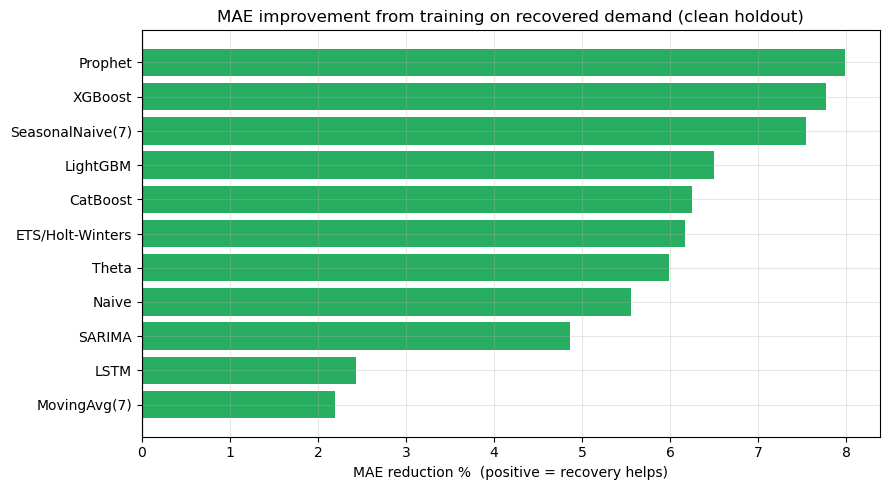

Feature-rich models mean MAE gain: +7.1%
Families where recovery cut |bias|: 5 of 11


In [15]:
def score(pred):
    d = pred.merge(truth, on=["uid","ds"]); d = d[d.n_oos == 0]; y = d["sale_amount"].values
    return {m: (mean_absolute_error(y, d[m]), (d[m]-y).mean()) for m in ZOO}, len(d)

sc, nclean = score(cen); sr, _ = score(rec)
lb = pd.DataFrame({
    "MAE_censored":  [sc[m][0] for m in ZOO], "MAE_recovered": [sr[m][0] for m in ZOO],
    "bias_censored": [sc[m][1] for m in ZOO], "bias_recovered":[sr[m][1] for m in ZOO],
}, index=ZOO)
lb["MAE_gain_%"] = (1 - lb.MAE_recovered / lb.MAE_censored) * 100
lb["|bias|_drop"] = lb.bias_censored.abs() - lb.bias_recovered.abs()
lb = lb.sort_values("MAE_gain_%", ascending=False)
print(f"clean holdout rows: {nclean}\n"); display(lb)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#27ae60" if v > 0 else "#c0392b" for v in lb["MAE_gain_%"]]
ax.barh(lb.index[::-1], lb["MAE_gain_%"][::-1], color=colors[::-1])
ax.axvline(0, color="k", lw=.8)
ax.set(title="MAE improvement from training on recovered demand (clean holdout)",
       xlabel="MAE reduction %  (positive = recovery helps)")
plt.tight_layout(); plt.show()

FEATURE_RICH = ["LightGBM","XGBoost","CatBoost","Prophet"]
print(f"Feature-rich models mean MAE gain: {lb.loc[FEATURE_RICH,'MAE_gain_%'].mean():+.1f}%")
print(f"Families where recovery cut |bias|: {(lb['|bias|_drop']>0).sum()} of {len(ZOO)}")

> **Insight — la recuperación no es un free lunch.** El beneficio cae en los modelos que
> pueden *localizar* la corrección: gradient boosting (LightGBM/XGBoost/CatBoost) y Prophet
> mejoran el MAE varios puntos y achican el sesgo, porque los lags, el calendario y las
> covariables les dejan aplicar el nivel de demanda más alto *de forma selectiva*. Los
> extrapoladores univariados puros (Naive, Media Móvil, ETS/Holt-Winters, Theta, SARIMA) solo
> suben su nivel y hasta pueden *pasarse* en el holdout limpio. La lección: recuperar el
> target es necesario, pero también necesitás un modelo lo bastante rico para usarlo. Por eso
> la recomendación de producción es un modelo basado en features sobre demanda recuperada — no
> un método clásico.


In [16]:
maeA, maeB = res.MAE.iloc[0], res.MAE.iloc[1]; bA, bB = res.bias.iloc[0], res.bias.iloc[1]
sp = seg.loc[seg.index.str.startswith("stockout")]
fr = lb.loc[FEATURE_RICH, "MAE_gain_%"].mean()
display(Markdown(f"""
### Headline finding (this sample, this setup)

Forecasting **observed sales** underestimates demand (bias **{bA:+.3f}**) because
~{(train.n_oos>0).mean():.0%} of days are censored by stockouts. Training the same model on
**recovered demand** nearly closes that bias (**{bB:+.3f}**) and cuts MAE
**{maeA:.3f} → {maeB:.3f}** ({(1-maeB/maeA):.0%}) on a *clean in-stock holdout*. The gain
concentrates **where censorship lives**: in stockout-prone series bias goes from
**{sp.bias_A.iloc[0]:+.3f}** to **{sp.bias_B.iloc[0]:+.3f}**; stable series are already fine.

**Recovery is not a free lunch.** Across {len(ZOO)} forecasting families, the benefit
concentrates in models that can *localize* the correction with features/covariates
(gradient boosting + Prophet: mean MAE gain **{fr:+.1f}%**); pure univariate extrapolators
(Naive, MA, ETS, Theta, ARIMA) cut MAE too but flip to positive bias on the clean
holdout. Hidden lost sales ≈ **{100*uplift.sum()/train.sale_amount.sum():.0f}%** of observed volume.
"""))


### Headline finding (this sample, this setup)

Forecasting **observed sales** underestimates demand (bias **-0.132**) because
~44% of days are censored by stockouts. Training the same model on
**recovered demand** nearly closes that bias (**-0.014**) and cuts MAE
**0.402 → 0.378** (6%) on a *clean in-stock holdout*. The gain
concentrates **where censorship lives**: in stockout-prone series bias goes from
**-0.154** to **-0.022**; stable series are already fine.

**Recovery is not a free lunch.** Across 11 forecasting families, the benefit
concentrates in models that can *localize* the correction with features/covariates
(gradient boosting + Prophet: mean MAE gain **+7.1%**); pure univariate extrapolators
(Naive, MA, ETS, Theta, ARIMA) cut MAE too but flip to positive bias on the clean
holdout. Hidden lost sales ≈ **19%** of observed volume.


## Fase 6 — Despliegue y limitaciones honestas

**El payoff de negocio.** La demanda recuperada hace *visible y cuantificable* la venta
perdida que el ERP nunca registra. Planear sobre ella sube la señal de pedido para los SKUs
propensos a quiebre — justo los que siguen quebrando porque el pronóstico se entrenó para
ignorar su demanda real.

**El gancho operativo.** Este pipeline asume que la censura está *etiquetada*. En producción
esa etiqueta viene de la **detección de disponibilidad en percha (OSA)** — visión
computacional sobre imágenes de góndola, IoT, o heurísticas de hueco en el POS. La capa de
CV/operaciones marca la percha vacía en tiempo real; este modelo convierte esa marca en una
señal de demanda corregida. Ese es el puente entre "una cámara vio una percha vacía" y "pide
más la próxima semana".

**Limitaciones y caveats honestos.**
- La demanda recuperada es una **estimación**, no verdad de campo — hereda el supuesto de
  imputación (las horas con stock representan la forma de demanda que habría habido). Nunca
  evaluamos contra ella.
- La evaluación en holdout limpio solo cubre días con stock; el comportamiento en días
  totalmente censurados es *inferido*, no medido.
- La mejora se concentra en series propensas a quiebre y en **modelos ricos en features**;
  para series estables, o para métodos clásicos univariados, los dos targets están cerca. Sin
  afirmaciones universales.
- Los números reflejan la muestra/config de esta corrida. Poné `N_SERIES = None` para el
  benchmark completo de 50,000 series y subí `MODEL_SAMPLE` para un zoo más grande.


In [17]:
lost = uplift.sum(); days = train.dt.nunique(); series = train.groupby(["store_id","product_id"]).ngroups
print(f"Sample: {series} series x {days} days")
print(f"Hidden lost units (latent demand):  {lost:,.0f}  ({lost/series/days:.3f} units/series/day)")
print(f"As share of observed sales:         {100*lost/train.sale_amount.sum():.1f}%")
for margin in (0.5, 1.0, 2.0):
    print(f"  @ {margin:.1f} margin/unit  ->  {lost*margin:,.0f} lost contribution (sample)")

Sample: 50000 series x 90 days
Hidden lost units (latent demand):  866,515  (0.193 units/series/day)
As share of observed sales:         19.3%
  @ 0.5 margin/unit  ->  433,257 lost contribution (sample)
  @ 1.0 margin/unit  ->  866,515 lost contribution (sample)
  @ 2.0 margin/unit  ->  1,733,030 lost contribution (sample)


**Traducción a disponibilidad (OSA).** Esa venta perdida no es un % abstracto: es una **brecha de servicio**. Si las unidades perdidas equivalen a ~19% de la venta observada, el negocio opera —en volumen potencial— a **~84% de disponibilidad real** (`OSA = observada / (observada + perdida)`). La diferencia entre lo que el ERP cree vender y lo que el cliente quiso comprar es la alarma que un director de Supply Chain entiende al instante.


In [18]:
# --- De venta perdida a puntos de disponibilidad (OSA potencial) ---
lost_pct = uplift.sum() / train.sale_amount.sum()
osa_real = 1 / (1 + lost_pct)
print(f"Venta perdida (oculta):              {100*lost_pct:.1f}% de la venta observada")
print(f"Disponibilidad real (OSA potencial): {100*osa_real:.1f}%")
print(f"Brecha de servicio oculta:           {100*(1-osa_real):.1f} pp")


Venta perdida (oculta):              19.3% de la venta observada
Disponibilidad real (OSA potencial): 83.8%
Brecha de servicio oculta:           16.2 pp
